In [2]:
import numpy as np
import math
import matplotlib.pyplot as plt
from IPython.display import display, Math

equation = lambda x: 2 ** x + x * x - 2
eps = 1e-3

# Метод Ньютона

Введём производные функции для метода Ньютона

In [3]:
ln2 = math.log(2)
derivative = lambda x: (2 ** x) * ln2 + 2 * x
second_derivative = lambda x: (2 ** x) * ln2 * ln2 + 2

Оценим начальное приближение графически

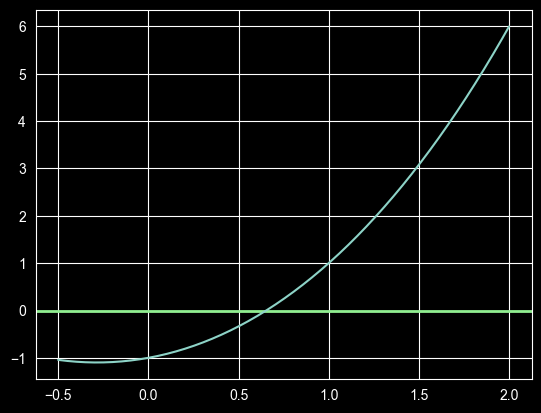

In [4]:
x = np.linspace(-0.5, 2, 200)
y = equation(x)

plt.axhline(0, color='lightgreen', linewidth=2)
plt.plot(x, y)
plt.grid(True)
plt.show()

Положим $x^{(0)} = 0.75$ и проверим условия сходимости метода.

In [5]:
x_i = x_prev = 0.75

equation(x_i) * second_derivative(x_i) > 0

True

In [6]:
condition = True
iterations = 0

while abs(condition) > eps:
    iterations += 1
    condition = equation(x_prev) / derivative(x_prev)
    x_i = x_prev - condition
    x_prev = x_i

x_newton = x_i
display(Math(fr"x_1 = {x_newton:.3f}"))
print(f"Iterations: {iterations}")

<IPython.core.display.Math object>

Iterations: 3


# Метод простых итераций

Ввёдём функцию $\phi(x) = \sqrt{2 - 2^x}$, которая является преобразованием уравнения $x = \phi(x)$.</br>
А также её производную для проверки сходимости метода простых итераций.

In [7]:
phi = lambda x: np.sqrt(2 - 2 ** x)
phi_derivative = lambda x: -ln2 * 2 ** (x - 1) / np.sqrt(2 - 2 ** x)

Проверим по теореме о условии сходимости метода и оценке его погрешности

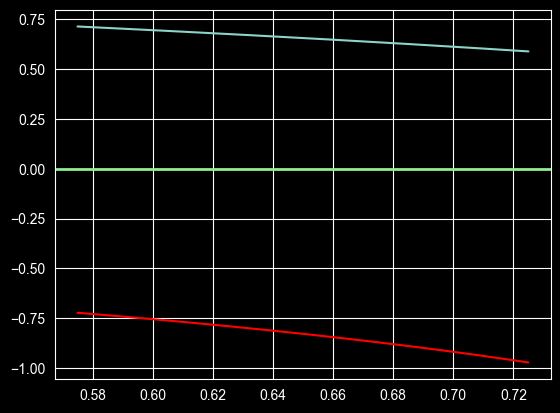

In [8]:
x = np.linspace(0.575, 0.725, 200)
y = phi(x)
y2 = phi_derivative(x)

plt.axhline(0, color='lightgreen', linewidth=2)
plt.plot(x, y)
plt.plot(x, y2, color='red')
plt.grid(True)
plt.show()

На рассматриваемом интервале $[0.575, 0.725]$ функция $\phi(x)$ и ёё производная непрерывны.</br>
Можно заметить, что производная по модулю меньше 1, значит метод простых итераций будет сходиться.</br>
Также все значения функции $\phi(x)$ на этом интервале лежат внутри него, что также гарантирует сходимость метода.

Проверим условия теоремы в коде

In [9]:
x[0] < phi(x[0])

np.True_

In [10]:
phi(x[-1]) < x[-1]

np.True_

In [11]:
abs(phi_derivative(x[-1])) < 1

np.True_

In [12]:
print(phi_derivative(x[-1]))

-0.972333622322209


In [13]:
x_i = 0
x_prev = (x[0] + x[-1]) / 2
q = 0.98
iterations = 0

condition = abs(x_i - x_prev) * q / (1 - q) > eps

while condition:
    iterations += 1
    x_i = phi(x_prev)
    condition = abs(x_i - x_prev) * q / (1 - q) > eps
    x_prev = x_i

x_iter = x_i
display(Math(fr"x_1 = {x_iter:.3f}"))
print(f"Iterations: {iterations}")

<IPython.core.display.Math object>

Iterations: 33


# Валидация

Используем scipy для проверки

In [14]:
from scipy.optimize import fsolve

root = fsolve(equation, 0.7)[0]

In [15]:
np.allclose(x_newton, root, eps)

True

In [16]:
np.allclose(x_iter, root, eps)

True